# HIICNN — Hybrid Image-Improving and CNN Stacking Ensemble for Traffic Sign Recognition

A GPU-accelerated pipeline for the GTSRB benchmark (43 German traffic sign
classes) combining classical image-enhancement preprocessing with a
stacking ensemble of three ImageNet-pretrained CNN backbones — **ResNet50**,
**VGG16**, and **EfficientNetB0** — fused by a learned meta-learner, with
latency/FPS reporting to support a real-time autonomous-driving framing.

**Pipeline:** enhance → resize/normalize → 3 backbones → concat softmax
outputs → meta-learner → final prediction.

**Expected dataset layout** (already downloaded, Kaggle-style GTSRB), next
to this notebook:

```
data/
├── Train/                # per-class subfolders (0..42)
├── Test/                 # flat folder of test images
├── Meta/
├── Train.csv             # Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
├── Test.csv
└── Meta.csv
```

Run the cells top to bottom. Training is the slow step — reduce
`NUM_EPOCHS` below for a quick smoke test before a full run.


## Imports


In [1]:
import os
import time
import json

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Edit these values to change dataset paths, image size, training hyperparameters, or which backbones are used.


In [2]:
# ---------------------------------------------------------------------------
# Paths — assumes this notebook lives at the project root, next to your
# already-downloaded data/ folder (Train/, Test/, Train.csv, Test.csv).
# ---------------------------------------------------------------------------
PROJECT_ROOT = os.getcwd()
DATA_ROOT = os.path.join(PROJECT_ROOT, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------
NUM_CLASSES = 43
IMAGE_SIZE = 96          # 64 or 96 both work with the backbones below
VAL_SPLIT = 0.1          # held out from Train.csv: used to monitor backbone
                         # training AND to generate the meta-learner's
                         # training data (proper stacking).
SEED = 42

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ---------------------------------------------------------------------------
# Image enhancement stage
# ---------------------------------------------------------------------------
USE_SHARPENING = True
USE_UNSHARP_MASK = True
USE_CLAHE_CONTRAST = True

# ---------------------------------------------------------------------------
# Backbones used in the stacking ensemble
# ---------------------------------------------------------------------------
BACKBONES = ["resnet50", "vgg16", "efficientnet_b0"]
FREEZE_BACKBONE = True     # freeze conv base, train only the new head

# ---------------------------------------------------------------------------
# Training hyperparameters
# ---------------------------------------------------------------------------
BATCH_SIZE = 64
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

# Meta-learner (stacking head)
META_HIDDEN_DIM = 64
META_EPOCHS = 60
META_LR = 1e-3

print(f"Using device: {DEVICE}")


Using device: cuda


## 1. Image Enhancement Stage

Three classical techniques, chained in this order, before resizing:

1. **CLAHE contrast enhancement** — adaptive histogram equalization on the
   L-channel of LAB space, to recover detail in over/under-exposed signs.
2. **Unsharp masking** — Gaussian-blur, subtract from the original, add
   back — boosts overall edge contrast.
3. **Sharpening convolution kernel** — a cheap 3x3 kernel for a final
   edge-emphasis pass, cheap enough to run per-frame in a real-time system.


In [3]:
def apply_clahe_contrast(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Contrast Limited Adaptive Histogram Equalization on the L channel of LAB space."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)


def apply_unsharp_mask(img, sigma=1.0, amount=1.5, threshold=0):
    """Classic unsharp masking: sharpened = original + amount * (original - blurred)."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1 + amount, blurred, -amount, 0)
    if threshold > 0:
        low_contrast_mask = np.abs(img.astype(int) - blurred.astype(int)) < threshold
        sharpened = np.where(low_contrast_mask, img, sharpened)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def apply_sharpening_kernel(img):
    """Edge-emphasizing 3x3 sharpening convolution kernel."""
    kernel = np.array([[0, -1, 0],
                        [-1, 5, -1],
                        [0, -1, 0]], dtype=np.float32)
    sharpened = cv2.filter2D(img, -1, kernel)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def enhance_image(img):
    """Full classical enhancement pipeline applied to a single RGB uint8 image."""
    out = img
    if USE_CLAHE_CONTRAST:
        out = apply_clahe_contrast(out)
    if USE_UNSHARP_MASK:
        out = apply_unsharp_mask(out)
    if USE_SHARPENING:
        out = apply_sharpening_kernel(out)
    return out


class EnhancementTransform:
    """Torchvision-compatible transform: PIL.Image -> enhanced PIL.Image."""

    def __call__(self, pil_img):
        arr = np.array(pil_img.convert("RGB"))
        enhanced = enhance_image(arr)
        return Image.fromarray(enhanced)


## 2. Dataset (Kaggle GTSRB CSV layout)


In [4]:
def _find_csv_columns(df):
    """Kaggle GTSRB CSVs consistently use
    Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path — tolerant of
    minor casing differences across mirrors."""
    cols = {c.lower(): c for c in df.columns}
    for required in ("path", "classid"):
        if required not in cols:
            raise ValueError(f"Expected a '{required}' column in the GTSRB csv, got columns: {list(df.columns)}")
    roi_names = ["roi.x1", "roi.y1", "roi.x2", "roi.y2"]
    roi_cols = [cols[r] for r in roi_names] if all(r in cols for r in roi_names) else None
    return cols["path"], cols["classid"], roi_cols


class GTSRBCSVDataset(Dataset):
    """Reads Train.csv or Test.csv and loads the corresponding images
    from disk, cropping to the annotated ROI when the columns are present."""

    def __init__(self, root, csv_name, transform=None):
        self.root = root
        self.transform = transform
        csv_path = os.path.join(root, csv_name)
        if not os.path.exists(csv_path):
            raise FileNotFoundError(
                f"Could not find {csv_path}.\n"
                f"Expected the Kaggle GTSRB layout under DATA_ROOT ({root}):\n"
                f"  Train.csv, Test.csv, Train/<classid>/*.png, Test/*.png"
            )
        df = pd.read_csv(csv_path)
        self.path_col, self.class_col, self.roi_cols = _find_csv_columns(df)
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, row[self.path_col])
        img = Image.open(img_path).convert("RGB")
        if self.roi_cols is not None:
            x1, y1, x2, y2 = (int(row[c]) for c in self.roi_cols)
            img = img.crop((x1, y1, x2, y2))
        label = int(row[self.class_col])
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def build_transforms(train=True):
    ops = [EnhancementTransform()]
    if train:
        ops += [
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
        ]
    ops += [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return transforms.Compose(ops)


def get_datasets():
    """Returns (train_ds, val_ds, test_ds). val_ds is carved out of
    Train.csv (not augmented) and is used both to monitor backbone
    training and to generate the meta-learner's training data."""
    train_tf = build_transforms(train=True)
    eval_tf = build_transforms(train=False)

    full_train_aug = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=train_tf)
    full_train_eval = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=eval_tf)

    n_total = len(full_train_aug)
    n_val = int(n_total * VAL_SPLIT)
    n_train = n_total - n_val

    generator = torch.Generator().manual_seed(SEED)
    train_subset, val_subset_idx = random_split(full_train_aug, [n_train, n_val], generator=generator)
    val_indices = val_subset_idx.indices
    val_subset = Subset(full_train_eval, val_indices)

    test_ds = GTSRBCSVDataset(DATA_ROOT, "Test.csv", transform=eval_tf)
    return train_subset, val_subset, test_ds


def get_dataloaders():
    train_ds, val_ds, test_ds = get_datasets()
    pin = DEVICE.type == "cuda"
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin)
    return train_loader, val_loader, test_loader


### Sanity check: raw vs. enhanced sample image


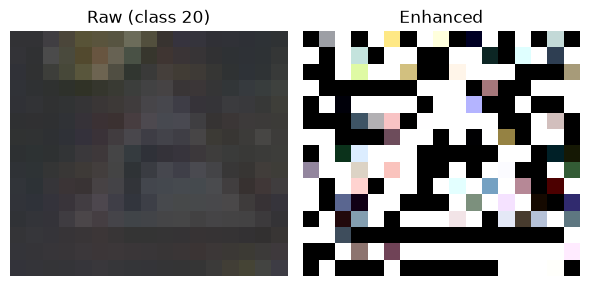

In [5]:
_demo_ds = GTSRBCSVDataset(DATA_ROOT, "Train.csv", transform=None)
_raw_img, _label = _demo_ds[0]
_enhanced_img = EnhancementTransform()(_raw_img)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(_raw_img); axes[0].set_title(f"Raw (class {_label})"); axes[0].axis("off")
axes[1].imshow(_enhanced_img); axes[1].set_title("Enhanced"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Base models (ResNet50, VGG16, EfficientNetB0) + stacking meta-learner


In [6]:
def _freeze(module):
    for p in module.parameters():
        p.requires_grad = False


def build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        _freeze(model)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


def build_vgg16(num_classes=NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        _freeze(model.features)
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


def build_efficientnet_b0(num_classes=NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        _freeze(model.features)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


BACKBONE_BUILDERS = {
    "resnet50": build_resnet50,
    "vgg16": build_vgg16,
    "efficientnet_b0": build_efficientnet_b0,
}


def build_backbone(name, num_classes=NUM_CLASSES, freeze_backbone=FREEZE_BACKBONE):
    if name not in BACKBONE_BUILDERS:
        raise ValueError(f"Unknown backbone '{name}'. Options: {list(BACKBONE_BUILDERS)}")
    return BACKBONE_BUILDERS[name](num_classes=num_classes, freeze_backbone=freeze_backbone)


class MetaLearner(nn.Module):
    """Small MLP stacking head: takes the concatenated softmax outputs of
    all base models and learns to weight/combine them into the final
    43-class prediction."""

    def __init__(self, num_backbones=len(BACKBONES), num_classes=NUM_CLASSES, hidden_dim=META_HIDDEN_DIM):
        super().__init__()
        in_dim = num_backbones * num_classes
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


## 4. Training functions


In [7]:
def train_one_backbone(name, train_loader, val_loader):
    print(f"\n{'='*60}\nTraining backbone: {name}\n{'='*60}")
    model = build_backbone(name).to(DEVICE)
    criterion = nn.CrossEntropyLoss()

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

    best_val_acc = 0.0
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"{name}.pt")

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, running_correct, n = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch+1}/{NUM_EPOCHS}")
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            n += imgs.size(0)
            pbar.set_postfix(loss=running_loss / n, acc=running_correct / n)

        val_acc = evaluate_accuracy(model, val_loader)
        scheduler.step(val_acc)
        print(f"[{name}] epoch {epoch+1}: train_acc={running_correct/n:.4f}  val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best ({val_acc:.4f}), saved to {ckpt_path}")

    print(f"Finished {name}. Best val acc: {best_val_acc:.4f}")
    return ckpt_path


@torch.no_grad()
def evaluate_accuracy(model, loader):
    model.eval()
    correct, n = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += imgs.size(0)
    return correct / n


@torch.no_grad()
def get_softmax_predictions(model, loader):
    """Runs a backbone over a loader and returns (probs, labels) as numpy arrays."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


def train_meta_learner(val_loader):
    print(f"\n{'='*60}\nTraining stacking meta-learner\n{'='*60}")
    backbone_probs = []
    labels = None
    for name in BACKBONES:
        model = build_backbone(name).to(DEVICE)
        model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, f"{name}.pt"), map_location=DEVICE))
        probs, lbls = get_softmax_predictions(model, val_loader)
        backbone_probs.append(probs)
        labels = lbls

    stacked_features = np.concatenate(backbone_probs, axis=1)
    X = torch.tensor(stacked_features, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(labels, dtype=torch.long).to(DEVICE)

    meta = MetaLearner().to(DEVICE)
    optimizer = optim.Adam(meta.parameters(), lr=META_LR)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(META_EPOCHS):
        meta.train()
        optimizer.zero_grad()
        out = meta(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            acc = (out.argmax(1) == y).float().mean().item()
            print(f"  meta epoch {epoch+1}/{META_EPOCHS}  loss={loss.item():.4f}  acc={acc:.4f}")

    ckpt_path = os.path.join(CHECKPOINT_DIR, "meta_learner.pt")
    torch.save(meta.state_dict(), ckpt_path)
    print(f"Meta-learner saved to {ckpt_path}")


## Run: build the dataloaders


In [8]:
train_loader, val_loader, test_loader = get_dataloaders()
print(f"train: {len(train_loader.dataset)}  val: {len(val_loader.dataset)}  test: {len(test_loader.dataset)}")


train: 35289  val: 3920  test: 12630


## Run: train all three backbones

This is the slow step. With a GPU this takes a while depending on
`NUM_EPOCHS`; on CPU it will be very slow — reduce `NUM_EPOCHS` in the
config cell above for a quick smoke test first.


In [9]:
for _name in BACKBONES:
    train_one_backbone(_name, train_loader, val_loader)



Training backbone: resnet50


[resnet50] epoch 1/12: 100%|██████████| 552/552 [05:40<00:00,  1.62it/s, acc=0.38, loss=2.13] 


[resnet50] epoch 1: train_acc=0.3798  val_acc=0.4791
  -> new best (0.4791), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints\resnet50.pt


[resnet50] epoch 2/12: 100%|██████████| 552/552 [01:11<00:00,  7.73it/s, acc=0.472, loss=1.7] 


[resnet50] epoch 2: train_acc=0.4724  val_acc=0.5240
  -> new best (0.5240), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints\resnet50.pt


...

[efficientnet_b0] epoch 10: train_acc=0.4695  val_acc=0.5503
  -> new best (0.5503), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints\efficientnet_b0.pt


[efficientnet_b0] epoch 11/12: 100%|██████████| 552/552 [01:03<00:00,  8.65it/s, acc=0.468, loss=1.67]


[efficientnet_b0] epoch 11: train_acc=0.4684  val_acc=0.5508
  -> new best (0.5508), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints\efficientnet_b0.pt


[efficientnet_b0] epoch 12/12: 100%|██████████| 552/552 [01:03<00:00,  8.70it/s, acc=0.477, loss=1.66]


[efficientnet_b0] epoch 12: train_acc=0.4770  val_acc=0.5538
  -> new best (0.5538), saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints\efficientnet_b0.pt
Finished efficientnet_b0. Best val acc: 0.5538


## Run: train the stacking meta-learner


In [10]:
train_meta_learner(val_loader)



Training stacking meta-learner
  meta epoch 10/60  loss=3.7029  acc=0.1416
  meta epoch 20/60  loss=3.6371  acc=0.2758
  meta epoch 30/60  loss=3.5474  acc=0.4005
  meta epoch 40/60  loss=3.4244  acc=0.4508
  meta epoch 50/60  loss=3.2679  acc=0.4722
  meta epoch 60/60  loss=3.0827  acc=0.4717
Meta-learner saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\checkpoints\meta_learner.pt


## 5. Evaluation — accuracy / precision / recall / F1 / confusion matrices


In [11]:
def load_trained_backbone(name, required=True):
    model = build_backbone(name).to(DEVICE)
    ckpt = os.path.join(CHECKPOINT_DIR, f"{name}.pt")
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    elif required:
        raise FileNotFoundError(f"No checkpoint found for '{name}' at {ckpt}. Train it first.")
    model.eval()
    return model


def load_meta_learner(required=True):
    meta = MetaLearner().to(DEVICE)
    ckpt = os.path.join(CHECKPOINT_DIR, "meta_learner.pt")
    if os.path.exists(ckpt):
        meta.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    elif required:
        raise FileNotFoundError(f"No meta-learner checkpoint found at {ckpt}. Train it first.")
    meta.eval()
    return meta


def compute_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    return {"model": name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 10))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    out_path = os.path.join(RESULTS_DIR, f"confusion_matrix_{name}.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved confusion matrix to {out_path}")


## Run: full evaluation on the GTSRB test set



--- resnet50 ---
Accuracy:  0.5169
Precision: 0.4425
Recall:    0.3995
F1-score:  0.4047


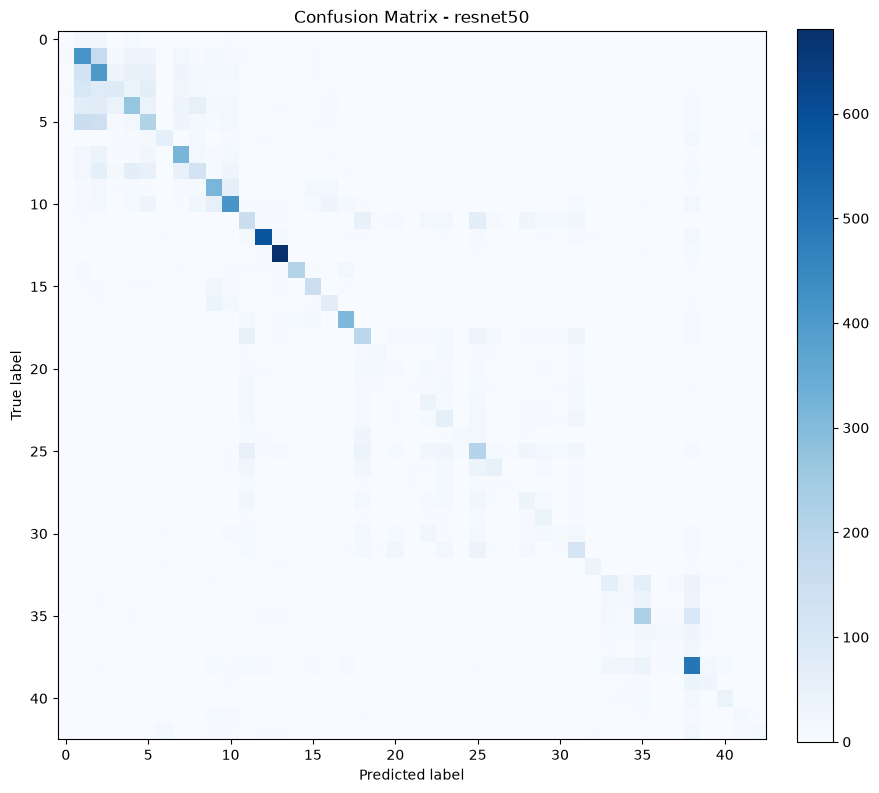

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results\confusion_matrix_resnet50.png

--- vgg16 ---
Accuracy:  0.5483
Precision: 0.4453
Recall:    0.3866
F1-score:  0.3818


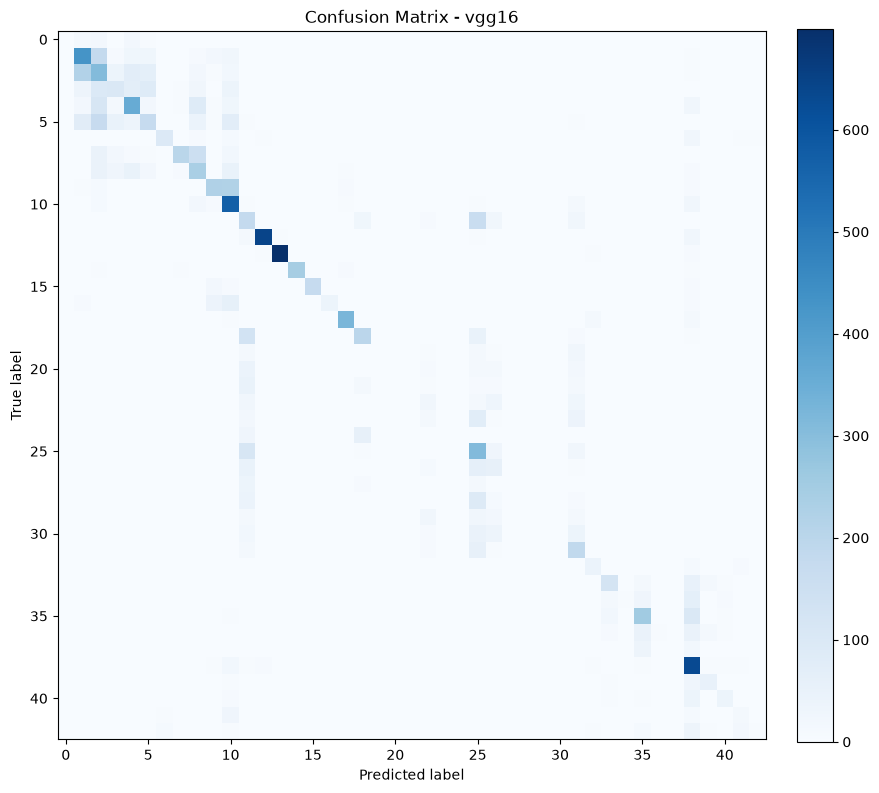

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results\confusion_matrix_vgg16.png

--- efficientnet_b0 ---
Accuracy:  0.4945
Precision: 0.4305
Recall:    0.3726
F1-score:  0.3815


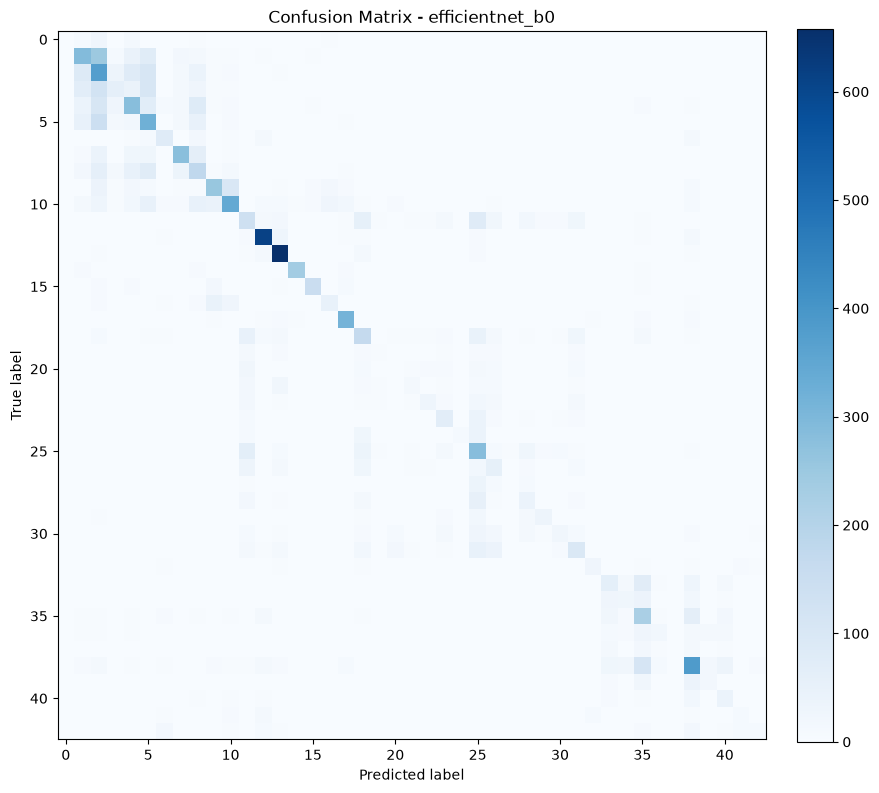

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results\confusion_matrix_efficientnet_b0.png

--- HIICNN_stacking_ensemble ---
Accuracy:  0.4537
Precision: 0.3654
Recall:    0.2629
F1-score:  0.2471


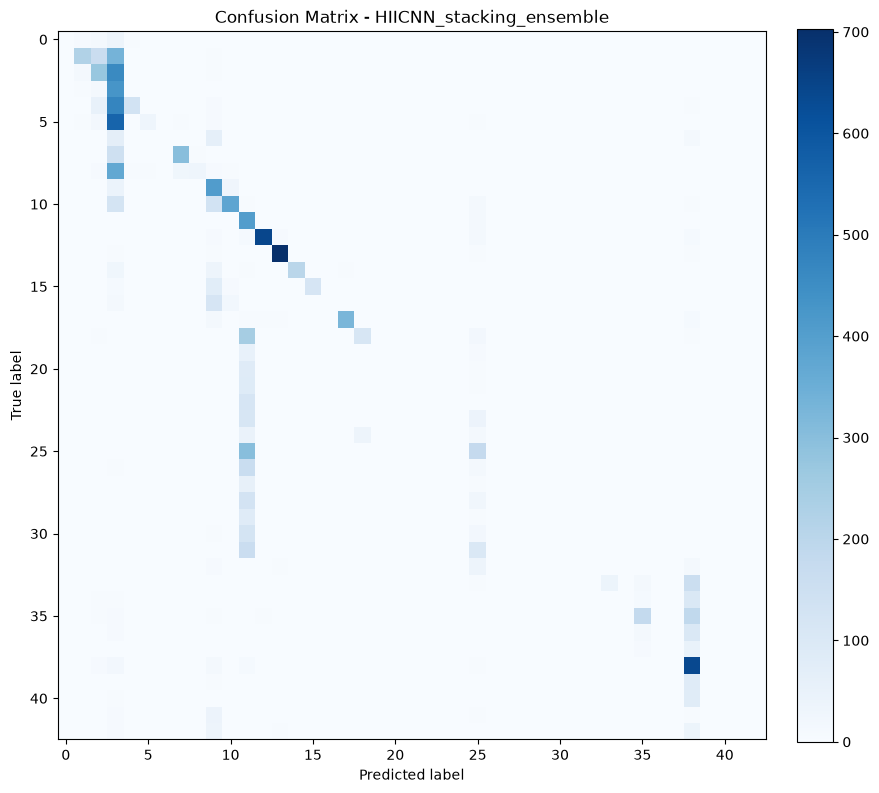

Saved confusion matrix to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results\confusion_matrix_HIICNN_stacking_ensemble.png

--- naive_average_ensemble ---
Accuracy:  0.6226
Precision: 0.5743
Recall:    0.4768
F1-score:  0.4894

Comparison table saved to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results\comparison_table.json

Model                          Accuracy  Precision     Recall         F1
resnet50                         0.5169     0.4425     0.3995     0.4047
vgg16                            0.5483     0.4453     0.3866     0.3818
efficientnet_b0                  0.4945     0.4305     0.3726     0.3815
HIICNN_stacking_ensemble         0.4537     0.3654     0.2629     0.2471
naive_average_ensemble           0.6226     0.5743     0.4768     0.4894


In [12]:
all_results = []
backbone_probs = {}
y_true = None

for _name in BACKBONES:
    _model = load_trained_backbone(_name)
    probs, labels = get_softmax_predictions(_model, test_loader)
    backbone_probs[_name] = probs
    y_true = labels
    y_pred = probs.argmax(axis=1)
    all_results.append(compute_metrics(y_true, y_pred, _name))
    plot_confusion_matrix(y_true, y_pred, _name)

# HIICNN stacking ensemble (trained meta-learner)
stacked = np.concatenate([backbone_probs[_name] for _name in BACKBONES], axis=1)
meta = load_meta_learner()
with torch.no_grad():
    X = torch.tensor(stacked, dtype=torch.float32).to(DEVICE)
    y_pred_ensemble = meta(X).argmax(1).cpu().numpy()

all_results.append(compute_metrics(y_true, y_pred_ensemble, "HIICNN_stacking_ensemble"))
plot_confusion_matrix(y_true, y_pred_ensemble, "HIICNN_stacking_ensemble")

# Naive-average ensemble, reported as a baseline the stacking meta-learner should beat
avg_probs = np.mean([backbone_probs[_name] for _name in BACKBONES], axis=0)
y_pred_avg = avg_probs.argmax(axis=1)
all_results.append(compute_metrics(y_true, y_pred_avg, "naive_average_ensemble"))

results_path = os.path.join(RESULTS_DIR, "comparison_table.json")
with open(results_path, "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nComparison table saved to {results_path}")

print("\n{:<28} {:>10} {:>10} {:>10} {:>10}".format("Model", "Accuracy", "Precision", "Recall", "F1"))
for r in all_results:
    print("{:<28} {:>10.4f} {:>10.4f} {:>10.4f} {:>10.4f}".format(
        r["model"], r["accuracy"], r["precision"], r["recall"], r["f1"]))


## 6. Real-time framing — inference latency (ms/image) and FPS


In [13]:
@torch.no_grad()
def benchmark_model(model, input_shape, n_warmup=20, n_runs=200, batch_size=1):
    model.eval()
    dummy = torch.randn(batch_size, *input_shape).to(DEVICE)

    for _ in range(n_warmup):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    ms_per_image = (elapsed / n_runs / batch_size) * 1000
    fps = 1000 / ms_per_image
    return ms_per_image, fps


class EnsembleWrapper(nn.Module):
    """Wraps the three backbones + meta-learner into a single forward
    pass, so the whole HIICNN pipeline's latency can be measured
    end-to-end, the way it would run in a deployed system."""

    def __init__(self, backbones, meta):
        super().__init__()
        self.backbones = nn.ModuleList(backbones)
        self.meta = meta

    def forward(self, x):
        probs = [torch.softmax(b(x), dim=1) for b in self.backbones]
        stacked = torch.cat(probs, dim=1)
        return self.meta(stacked)


## Run: benchmark latency and FPS


In [14]:
if DEVICE.type != "cuda":
    print("WARNING: no CUDA GPU detected — these numbers won't reflect the "
          "real-time GPU-inference framing.")

input_shape = (3, IMAGE_SIZE, IMAGE_SIZE)
bench_results = []
bench_backbones = []

for _name in BACKBONES:
    _model = load_trained_backbone(_name, required=False)
    bench_backbones.append(_model)
    ms, fps = benchmark_model(_model, input_shape)
    print(f"{_name:>18}: {ms:6.2f} ms/image  |  {fps:7.1f} FPS")
    bench_results.append({"model": _name, "ms_per_image": ms, "fps": fps})

_meta = load_meta_learner(required=False)
_ensemble = EnsembleWrapper(bench_backbones, _meta).to(DEVICE)
ms, fps = benchmark_model(_ensemble, input_shape)
print(f"{'HIICNN ensemble':>18}: {ms:6.2f} ms/image  |  {fps:7.1f} FPS")
bench_results.append({"model": "HIICNN_stacking_ensemble", "ms_per_image": ms, "fps": fps})

bench_path = os.path.join(RESULTS_DIR, "latency_benchmark.json")
with open(bench_path, "w") as f:
    json.dump(bench_results, f, indent=2)
print(f"\nSaved benchmark results to {bench_path}")


          resnet50:   3.44 ms/image  |    290.6 FPS
             vgg16:   2.74 ms/image  |    365.3 FPS
   efficientnet_b0:   4.61 ms/image  |    217.1 FPS
   HIICNN ensemble:   9.00 ms/image  |    111.1 FPS

Saved benchmark results to c:\Users\Mohammed Elidrissi\Desktop\evaluation-framework-for-LLMs-VLM\results\latency_benchmark.json
